### Env

In [ ]:
import transformers
from transformers import AutoModel, BertModel, AutoTokenizer, BertTokenizer, get_linear_schedule_with_warmup
import torch
from torch.optim import AdamW

import numpy as np
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from collections import defaultdict
from textwrap import wrap

from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

%matplotlib inline
%config InlineBackend.figure_format='retina'

from google.colab import drive
drive.mount('/content/drive')
df_raw = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/0-S2Group/BERT/src/tweets_cleaned.csv")
df= df_raw[['processed_text', 'airline_sentiment']]
df.to_csv("/content/drive/MyDrive/Colab Notebooks/0-S2Group/BERT/src/tweets_lite.csv", index=False)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


device(type='cuda', index=0)

In [ ]:
PRE_TRAINED_MODEL_NAME = 'bert-base-cased'
#PRE_TRAINED_MODEL_NAME = 'FacebookAI/roberta-base'
#PRE_TRAINED_MODEL_NAME = 'distilroberta-base'

tokenizer = AutoTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
class_names = ['neutral', 'positive', 'negative']
MAX_LEN = 32 # Based on EDA part
df.shape

(14100, 2)

### Dataset

In [ ]:
class TwitterDataset(Dataset):

  def __init__(self, reviews, targets, tokenizer, max_len):
    self.reviews = reviews
    self.targets = targets
    self.tokenizer = tokenizer
    self.max_len = max_len

  def __len__(self):
    return len(self.reviews)

  def __getitem__(self, item):
    review = str(self.reviews[item])
    target = self.targets[item]
    if target == 'neutral':
       target = 0
    elif target == 'positive':
       target = 1
    else:
       target = 2

    encoding = self.tokenizer(
      review,
      add_special_tokens=True,
      truncation=True,
      max_length=self.max_len,
      return_token_type_ids=False,
      padding='max_length',
      return_attention_mask=True,
      return_tensors='pt',
    )

    return {
      'review_text': review,
      'input_ids': encoding['input_ids'].flatten(),
      'attention_mask': encoding['attention_mask'].flatten(),
      'targets': torch.tensor(target, dtype=torch.long)
    }

### Split

In [ ]:
df_train, df_temp = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df['airline_sentiment']
)

df_val, df_test = train_test_split(
    df_temp,
    test_size=0.5,
    random_state=42,
    stratify=df_temp['airline_sentiment']
)

df_train.shape, df_val.shape, df_test.shape

((9870, 2), (2115, 2), (2115, 2))

### Data Loader

In [ ]:
def create_data_loader(df, tokenizer, max_len, batch_size):
  ds = TwitterDataset(
    reviews=df.processed_text.to_numpy(),
    targets=df.airline_sentiment.to_numpy(),
    tokenizer=tokenizer,
    max_len=max_len,
  )

  return DataLoader(
    ds,
    batch_size=batch_size,
    num_workers=0,
    shuffle=True   # drop_last=True
  )

In [ ]:
BATCH_SIZE = 32

train_data_loader = create_data_loader(df_train, tokenizer, MAX_LEN, BATCH_SIZE)
val_data_loader = create_data_loader(df_val, tokenizer, MAX_LEN, BATCH_SIZE)
test_data_loader = create_data_loader(df_test, tokenizer, MAX_LEN, BATCH_SIZE)

### Model

In [ ]:
class SentimentClassifier(nn.Module):

  def __init__(self, n_classes):
    super(SentimentClassifier, self).__init__()
    self.bert = AutoModel.from_pretrained(PRE_TRAINED_MODEL_NAME)
    self.drop = nn.Dropout(p=0.3)
    self.out = nn.Linear(self.bert.config.hidden_size, n_classes)

  def forward(self, input_ids, attention_mask):
    outputs = self.bert(
      input_ids=input_ids,
      attention_mask=attention_mask
    )
    output = self.drop(outputs.pooler_output)
    return self.out(output)

### Initialize

In [ ]:
model = SentimentClassifier(len(class_names))
model = model.to(device)

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Training

In [ ]:
EPOCHS = 10

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_data_loader) * EPOCHS

# if 10% warmup is used, set num_warmup_steps to int(0.1 * total_steps)
scheduler = get_linear_schedule_with_warmup(
  optimizer,
  num_warmup_steps=0,
  num_training_steps=total_steps
)

loss_fn = nn.CrossEntropyLoss().to(device)

In [ ]:
def train_epoch(model, data_loader, loss_fn, optimizer, device, scheduler, n_examples):
  model = model.train()

  losses = []
  correct_predictions = 0

  for d in data_loader:
    input_ids = d["input_ids"].to(device)
    attention_mask = d["attention_mask"].to(device)
    targets = d["targets"].to(device)

    outputs = model(
      input_ids=input_ids,
      attention_mask=attention_mask
    )

    _, preds = torch.max(outputs, dim=1)
    loss = loss_fn(outputs, targets)

    correct_predictions += torch.sum(preds == targets)
    losses.append(loss.item())

    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()
    optimizer.zero_grad()

  return correct_predictions.double() / n_examples, np.mean(losses)

In [ ]:
def eval_model(model, data_loader, loss_fn, device, n_examples):
  model = model.eval()

  losses = []
  correct_predictions = 0

  with torch.no_grad():
    for d in data_loader:
      input_ids = d["input_ids"].to(device)
      attention_mask = d["attention_mask"].to(device)
      targets = d["targets"].to(device)

      outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
      )
      _, preds = torch.max(outputs, dim=1)

      loss = loss_fn(outputs, targets)

      correct_predictions += torch.sum(preds == targets)
      losses.append(loss.item())

  return correct_predictions.double() / n_examples, np.mean(losses)

### Training Loop

In [ ]:
%%time

history = defaultdict(list)
best_accuracy = 0
patience = 5
counter = 0

for epoch in range(EPOCHS):

  print(f'Epoch {epoch + 1}/{EPOCHS}')
  print('-' * 10)

  train_acc, train_loss = train_epoch(model, train_data_loader, loss_fn, optimizer, device, scheduler, len(df_train))

  print(f'Train loss {train_loss} accuracy {train_acc}')

  val_acc, val_loss = eval_model(model, val_data_loader, loss_fn, device, len(df_val))

  print(f'Val   loss {val_loss} accuracy {val_acc}')
  print()

  if val_acc > best_accuracy:
    torch.save(model.state_dict(), 'best_model_state.bin')
    best_accuracy = val_acc
    counter = 0
  else:
    counter += 1
    if counter >= patience:
      break

  history['train_acc'].append(train_acc.cpu().detach().numpy())
  history['train_loss'].append(train_loss)
  history['val_acc'].append(val_acc.cpu().detach().numpy())
  history['val_loss'].append(val_loss)

Epoch 1/10
----------
Train loss 0.601121679864655 accuracy 0.7569402228976696
Val   loss 0.483850232478398 accuracy 0.808983451536643

Epoch 2/10
----------
Train loss 0.3930750153838238 accuracy 0.8527862208713272
Val   loss 0.5170469868983796 accuracy 0.808983451536643

Epoch 3/10
----------
Train loss 0.25966727855377214 accuracy 0.9090172239108408
Val   loss 0.6086398872421749 accuracy 0.7995271867612292

Epoch 4/10
----------
Train loss 0.15802630756508473 accuracy 0.9483282674772036
Val   loss 0.7558214513223562 accuracy 0.7995271867612292

Epoch 5/10
----------
Train loss 0.10369240724810166 accuracy 0.9671732522796352
Val   loss 0.8967106861423757 accuracy 0.8061465721040189

Epoch 6/10
----------
Train loss 0.06866772417664757 accuracy 0.9800405268490374
Val   loss 1.0248397706465713 accuracy 0.8042553191489361

CPU times: user 6min 37s, sys: 908 ms, total: 6min 38s
Wall time: 6min 48s


### Report

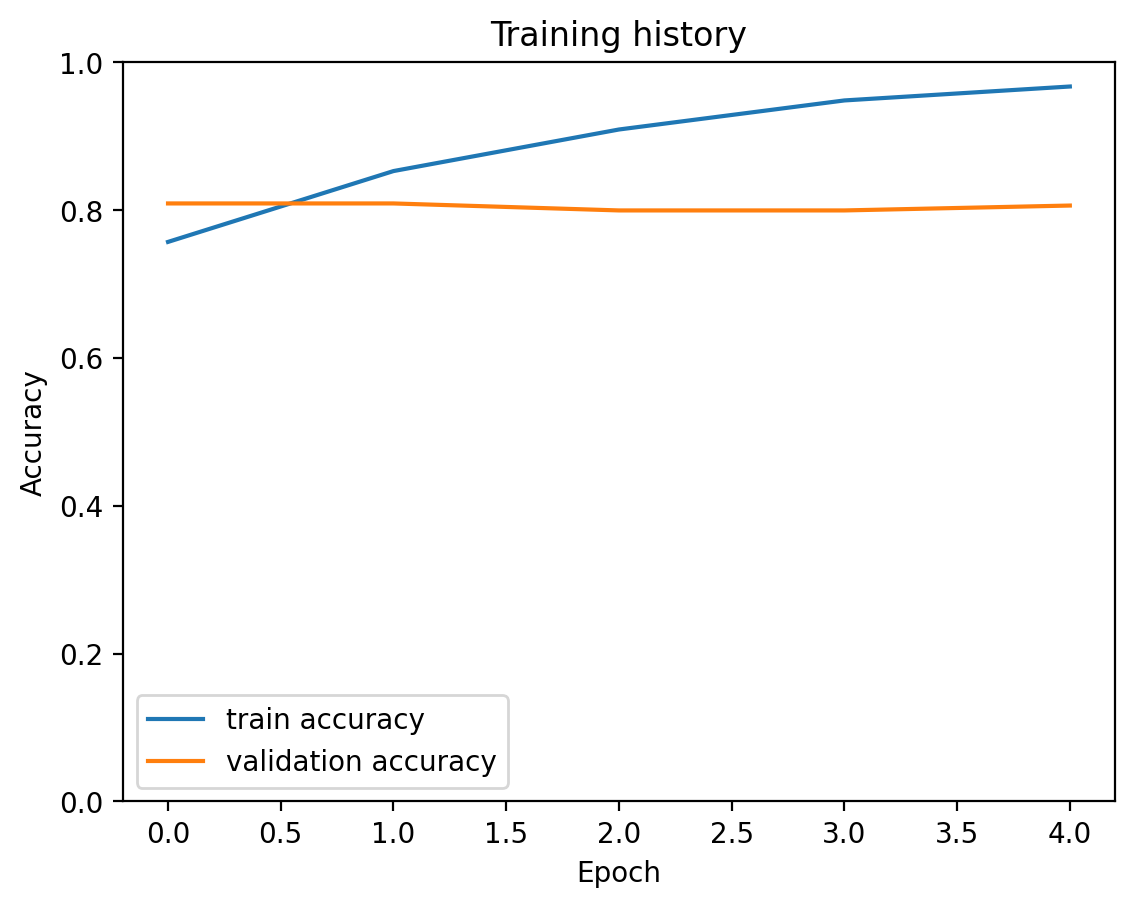

In [ ]:
plt.plot(history['train_acc'], label='train accuracy')
plt.plot(history['val_acc'], label='validation accuracy')

plt.title('Training history')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.ylim([0, 1]);

In [ ]:
model.load_state_dict(torch.load('best_model_state.bin', weights_only=False))  # load the best model
model = model.to(device)

test_acc, test_loss = eval_model(model, test_data_loader, loss_fn, device, len(df_test))

test_acc.item(), test_loss.item()

(0.8208037825059101, 0.4851424013500783)

In [ ]:
def get_predictions(model, data_loader):
  model = model.eval()

  review_texts = []
  predictions = []
  prediction_probs = []
  real_values = []

  with torch.no_grad():
    for d in data_loader:

      texts = d["review_text"]
      input_ids = d["input_ids"].to(device)
      attention_mask = d["attention_mask"].to(device)
      targets = d["targets"].to(device)

      outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
      )
      _, preds = torch.max(outputs, dim=1)

      probs = F.softmax(outputs, dim=1)

      review_texts.extend(texts)
      predictions.extend(preds)
      prediction_probs.extend(probs)
      real_values.extend(targets)

  predictions = torch.stack(predictions).cpu()
  prediction_probs = torch.stack(prediction_probs).cpu()
  real_values = torch.stack(real_values).cpu()
  return review_texts, predictions, prediction_probs, real_values

In [ ]:
y_review_texts, y_pred, y_pred_probs, y_test = get_predictions(model, test_data_loader)
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

     neutral       0.74      0.50      0.60       436
    positive       0.77      0.73      0.75       323
    negative       0.85      0.94      0.89      1356

    accuracy                           0.82      2115
   macro avg       0.79      0.73      0.75      2115
weighted avg       0.81      0.82      0.81      2115



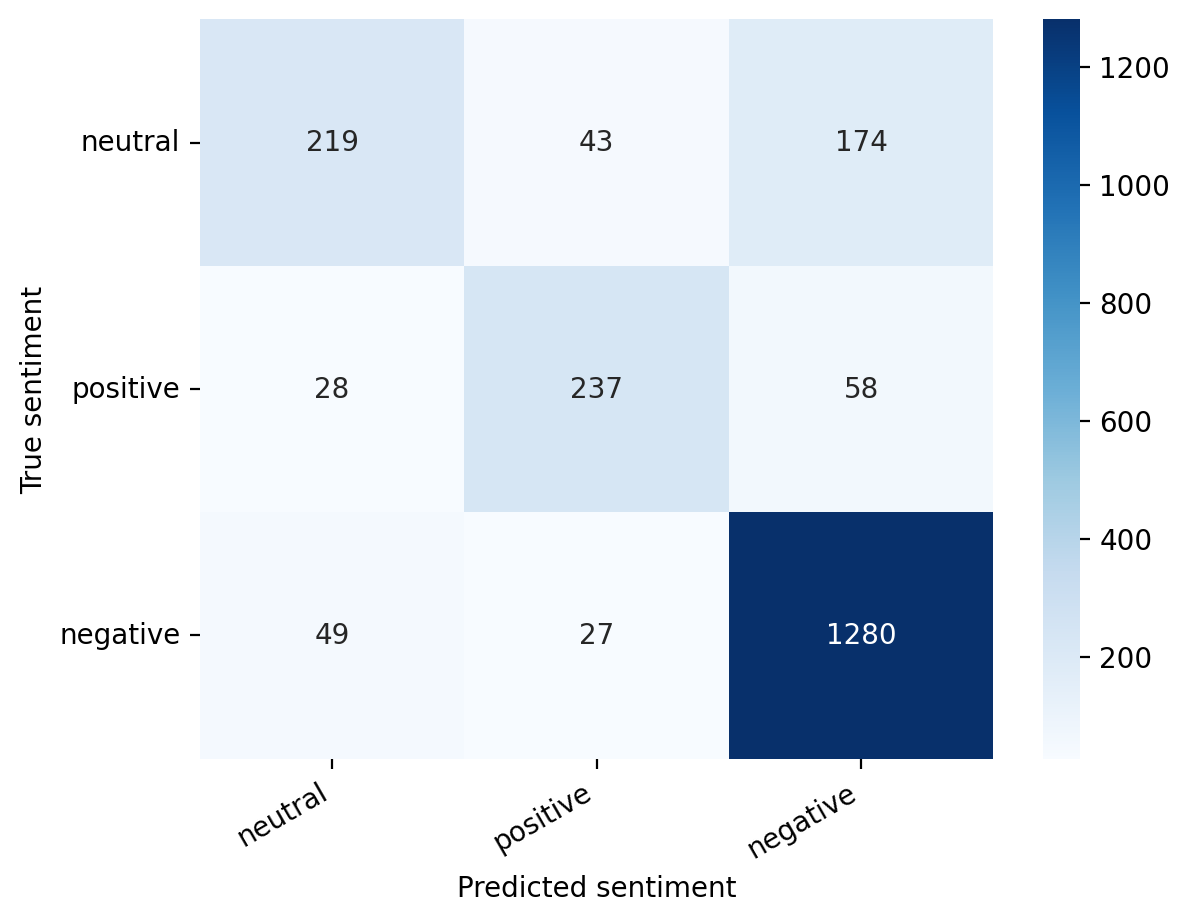

In [ ]:
def show_confusion_matrix(confusion_matrix):
  hmap = sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
  hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
  hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
  plt.ylabel('True sentiment')
  plt.xlabel('Predicted sentiment');

cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
show_confusion_matrix(df_cm)